
# Homework 1: Eigenflowers (PCA on Images)

This notebook walks through an **end-to-end PCA pipeline** on a non-face image dataset (**Oxford Flowers**).  
You will:
- Preprocess images (grayscale, resize, flatten)
- Build the data matrix `A` (pixels × samples)
- Compute PCA via **dual trick** (`L = AᵀA / M`) **or** via **thin SVD**
- Visualize the **mean image** and **top eigenimages** ("eigenflowers")
- Reconstruct images using the top-k components and evaluate error

> **For homework 1:** This notebook is commented and includes **TODO** markers.  
> Please add your implementation where the **TODO** markers are, including code and Markdown cells.



## 0) Environment & Imports

We will use the standard scientific Python packages (`numpy`, `PIL`, `matplotlib`) along with `hashlib`.   
Note that each student should have their own unique seed for repeatability.   
Make sure your kernel uses Python ≥ 3.8.


In [25]:
# Imports
import os
import csv
import numpy as np
import hashlib
from PIL import Image
import matplotlib.pyplot as plt

# NOTE: sklearn is imported only in the Bonus T-SNE cell at the end,
#       so the core notebook runs without scikit-learn installed.

# Set a fixed random seed for reproducibility
# NOTE: Replace TOKEN with the last 4 digits of your UB person number
TOKEN = "9882"  # <-- TODO: Replace with your last 4 digits of UB person number
SEED = int(hashlib.sha256(TOKEN.encode()).hexdigest(), 16) % (10**6)
np.random.seed(SEED)
print("SEED:", SEED)

# Matplotlib defaults
plt.rcParams["figure.figsize"] = (5, 4)
plt.rcParams["axes.grid"] = True

SEED: 543098



## 1) Point to your dataset

- Download and extract **Flowers dataset** (from the given image folder) locally.
- Set `DATA_DIR` to the folder containing the training images.
- Choose a target size (e.g., **64×64**) and an optional cap on images for quick experiments.


In [26]:
# === YOUR INPUTS ===
DATA_DIR    = "./dataset/train"   # path to training images
TEST_DIR    = "./dataset/test"    # path to test images
OUTPUT_SIZE = (64, 64)            # resize all images to this size
MAX_IMAGES  = 100                 # set to None for all, or int to cap


## 2) Preprocessing helpers

We have small utilities for you to:
- Walk the dataset directory
- Convert to **grayscale**
- **Resize** to the same size
- **Flatten** to vectors and **normalize** to `[0,1]`
- Stack as columns into the data matrix **A** of shape `(pixels, M)`


In [27]:
def load_and_preprocess(data_dir, size=(64, 64), max_images=None):
    '''
    Load images recursively from 'data_dir'.
    Convert to grayscale, resize to 'size', flatten, normalize to [0,1].
    Returns:
      A: np.ndarray shape (pixels, M)  -- data matrix (columns are images)
      paths: list[str]                 -- list of file paths used (length M)
    '''
    vectors = []
    paths = []
    for root, _, files in os.walk(data_dir):
        for fn in sorted(files):  # sort for reproducibility
            if fn.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                path = os.path.join(root, fn)
                try:
                    img = Image.open(path).convert('L').resize(size)  # grayscale + resize
                    vec = np.asarray(img, dtype=np.float32).flatten() / 255.0
                    vectors.append(vec)
                    paths.append(path)
                    if max_images is not None and len(vectors) >= max_images:
                        break
                except Exception as e:
                    print(f'[warn] Skipping {path}: {e}')
        if max_images is not None and len(vectors) >= max_images:
            break

    if not vectors:
        raise RuntimeError('No images found. Check your DATA_DIR and file extensions.')

    A = np.column_stack(vectors)  # shape: (pixels, M)
    return A, paths

print("Helper 'load_and_preprocess' defined.")

Helper 'load_and_preprocess' defined.



## 3) Load & preprocess images

You may want to use only a small number of images and make them small (32x32) while coding and debugging


In [28]:
# Load training images
A, paths = load_and_preprocess(DATA_DIR, size=OUTPUT_SIZE, max_images=MAX_IMAGES)
print("A.shape (pixels x M):", A.shape)
print("Number of training images loaded:", A.shape[1])
print("Example paths (first 3):", paths[:3])

A.shape (pixels x M): (4096, 30)
Number of training images loaded: 30
Example paths (first 3): ['./dataset/train/image_04019.jpg', './dataset/train/image_04044.jpg', './dataset/train/image_04048.jpg']



## 4) TODO: Mean image & centering

PCA expects **mean-centered** data.  
- Compute the **mean image** across columns of `A`  
- Subtract it from each column to get `A_centered`


mean_image.shape: (4096,)
A_centered.shape: (4096, 30)


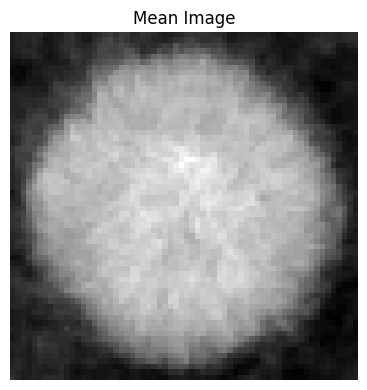

In [29]:
# Compute the mean image (average pixel value across all M training images)
mean_image = np.mean(A, axis=1)  # shape: (pixels,)

# Center the data: subtract mean from every column
A_centered = A - mean_image[:, None]  # shape: (pixels, M)

print("mean_image.shape:", mean_image.shape)
print("A_centered.shape:", A_centered.shape)

# Visualise the mean image — should look like a blurry flower
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape(OUTPUT_SIZE[::-1]), cmap='gray')
plt.title('Mean Image')
plt.axis('off')
plt.tight_layout()
plt.show()

## 5) TODO: Implement PCA (Method 1): Thin SVD

Compute SVD of `A_centered` directly: 
You can use the `SVD` function from the `linalg` library in numpy
> $A_{\text{centered}} = U \Sigma V^\top$

- Covariance eigenvalues: $\lambda_i = \frac{1}{M}\sigma_i^2$  
- Eigenimages (eigenvectors) are the columns of $U$

> **This metod is often numerically preferred as it is more stable**

In [30]:
def pca_svd(A_centered, num_components=None):
    '''
    PCA via thin SVD.
    Returns:
      U_k: eigenimages (pixels x k), orthonormal columns
      eigvals_k: covariance eigenvalues (length k), sorted descending
    '''
    M = A_centered.shape[1]

    # Thin (economy) SVD:  A_centered = U @ diag(s) @ Vt
    # full_matrices=False gives shapes (pixels, min(p,M)), (min(p,M),), (min(p,M), M)
    U, s, Vt = np.linalg.svd(A_centered, full_matrices=False)

    # Covariance eigenvalues: lambda_i = sigma_i^2 / M
    # SVD already returns singular values in descending order
    eigvals = (s ** 2) / M

    if num_components is not None:
        U       = U[:, :num_components]
        eigvals = eigvals[:num_components]

    return U, eigvals

print("Helper 'pca_svd' defined.")

Helper 'pca_svd' defined.



## 6) TODO: PCA (Method 2a): Dual trick

Compute eigenpairs of the small **sample–sample** $L$ matrix given $A_{\text{centered}}$:

$L = \frac{1}{M} A^\top A \in \mathcal{R}^{M \times M}$,

- Solve $L v_i = \lambda_i v_i$; You can use the prebuilt linear algebra $\texttt{eigvals, V = np.linalg.eigh}$ function call
- This will return the eigen values and vectors in $\textbf{ascending}$ order; you want to reverse this order
- Now map this back into the feature space: $u_i = A_{\text{centered}}\; v_i$
- Normalize each $u_i$ to unit length

In [31]:
def pca_dual(A_centered, num_components=None):
    '''
    PCA via dual trick: eigendecompose L = (A^T A)/M, then map back to feature space.
    Returns:
      U: eigenimages as columns (pixels x k), unit-norm
      eigvals: covariance eigenvalues (length k), sorted descending
    '''
    M = A_centered.shape[1]

    # Build the small M x M gram matrix L = A^T A / M
    L = (A_centered.T @ A_centered) / M  # shape: (M, M)

    # np.linalg.eigh returns eigenvalues in ASCENDING order (symmetric matrix)
    eigvals_L, V = np.linalg.eigh(L)  # V columns are eigenvectors

    # Reverse to DESCENDING order
    eigvals_L = eigvals_L[::-1]
    V         = V[:, ::-1]

    # Lift eigenvectors of L back to pixel space:  u_i = A_centered @ v_i
    U = A_centered @ V  # shape: (pixels, M)

    # Normalise each column of U to unit length
    norms = np.linalg.norm(U, axis=0, keepdims=True)
    norms[norms < 1e-12] = 1.0  # guard against division by zero
    U = U / norms

    if num_components is not None:
        U         = U[:, :num_components]
        eigvals_L = eigvals_L[:num_components]

    return U, eigvals_L

print("Helper 'pca_dual' defined.")

Helper 'pca_dual' defined.


## 7) TODO: PCA (Method 2b): Dual trick + Eigendecomposition using the Power Method

Again we want to compute eigenpairs of the $L$ matrix, but this time we will use the **power method**:

- We again want to solve $L v_i = \lambda_i v_i$
- We will implement our own version of the power method
>   We will write 2 auxilliary functions to aid with this
- Like before, the power method will return the eigen values and vectors, but in descending order
- Now map this back into the feature space: $u_i = A_{\text{centered}}\; v_i$
- Normalize each $u_i$ to unit length

### Aux 1) TODO: The Power Method for the most dominant eigenpair (single)   
$\textbf{GOAL:}$ Approximate the dominant eigenvalue $\lambda_{\max}$ and corresponding eigenvector $v_{\max}$ of a matrix $L \in \mathbb{R}^{m \times m}$.

PSEUDOCODE FOR POWER METHOD:
1. Create a random vector $x_0$ of length $\texttt{L.shape[0]}$  
   - Normalize the vector via $\frac{x_0}{\|x_0\|}$  
   - Set $\lambda_0 = 0.0$ <br>

2. For $k = 1, 2, \dots, \texttt{num\_iter}$
    - Multiply: $y_k = L x_{k-1}$ 
    - Normalize: $x_k = \tfrac{y_k}{\|y_k\|}$
    - Rayleigh quotient: $\lambda_k = x_k^\top L x_k$
    - if $|\lambda_k - \lambda_{k-1}| \le \epsilon$; BREAK   

3. Output $(\lambda_k, x_k)$ as approximation of the dominant eigenpair.

$\textbf{Note:}$ these are all matrix multiplications - use the operator "@"


In [32]:
def power_method_sym(L, num_iters=200, tol=1e-12, x0=None):
    '''
    Power method for the dominant eigenpair of a symmetric matrix L.
    Returns:
      lam: the most dominant eigenvalue of L
      x:   the corresponding eigenvector (unit-norm)
    '''
    m = L.shape[0]

    # Step 1: initialise and normalise the starting vector
    if x0 is None:
        x = np.random.randn(m)
    else:
        x = x0.copy().astype(float)
    x   = x / np.linalg.norm(x)
    lam = 0.0

    # Step 2: iterate
    for _ in range(num_iters):
        # Multiply: y = L x
        y = L @ x

        # Normalise: x = y / ||y||
        norm_y = np.linalg.norm(y)
        if norm_y < 1e-14:   # matrix-vector product is essentially zero
            break
        x = y / norm_y

        # Rayleigh quotient: lambda = x^T L x
        lam_new = float(x @ (L @ x))

        # Convergence check
        if abs(lam_new - lam) <= tol:
            lam = lam_new
            break
        lam = lam_new

    return lam, x

print("Helper 'power_method_sym' defined.")

Helper 'power_method_sym' defined.


### Aux 2) TODO: The Power Method to compute the top-k eigenpairs of L (symmetrical)

$k = \min(k, m)$; where $m$ is $\texttt{L.shape[0]}$  

For $i = 1, 2, \dots, k$   
   - call $\lambda_k, v_k =$ power_method_sym$(L)$
   - next perform a $\textbf{rank-1 deflation}$ of $L$:
      - set $L \leftarrow L - \lambda_k v_k v_k^\top$
      - repeat the power method on deflations of $L$ to get the remaining eigenpairs in a descending order of $\lambda$'s


In [33]:
def power_method_sym_allk(L, k=None, num_iters=200, tol=1e-8):
    '''
    Compute the top-k eigenpairs of a symmetric matrix L
    using power iteration with rank-1 deflation.
    Returns:
      lambdas: 1-D array of k eigenvalues (descending order)
      V:       (m, k) matrix whose columns are the corresponding eigenvectors
    '''
    m = L.shape[0]
    if k is None:
        k = m
    k = min(k, m)

    L_work  = L.copy().astype(float)
    lambdas = []
    eigvecs = []

    for _ in range(k):
        # Find dominant eigenpair of the (possibly deflated) matrix
        lam, v = power_method_sym(L_work, num_iters=num_iters, tol=tol)
        lambdas.append(lam)
        eigvecs.append(v)

        # Rank-1 deflation: remove contribution of this eigenpair
        #   L <- L - lambda * v v^T
        L_work = L_work - lam * np.outer(v, v)

    lambdas = np.array(lambdas)         # shape: (k,)
    V       = np.column_stack(eigvecs)  # shape: (m, k)

    return lambdas, V

print("Helper 'power_method_sym_allk' defined.")

Helper 'power_method_sym_allk' defined.


### TODO: Now implement pca_dualpower 

Use the the same signature as the other PCA calls; use your auxilliary methods to get the same return values

In [34]:
def pca_dualpower(A_centered, num_components=None):
    '''
    PCA via dual trick using our own handwritten Power Method.
    Returns:
      U: eigenimages as columns (pixels x k), unit-norm
      eigvals: covariance eigenvalues (length k), sorted descending
    '''
    M = A_centered.shape[1]

    # Build the small M x M gram matrix L = A^T A / M
    L = (A_centered.T @ A_centered) / M  # shape: (M, M)

    # Determine how many components to compute
    k = M if num_components is None else min(num_components, M)

    # Get top-k eigenpairs via power method with rank-1 deflation
    eigvals, V = power_method_sym_allk(L, k=k, num_iters=500, tol=1e-10)

    # Lift back to pixel space:  u_i = A_centered @ v_i
    U = A_centered @ V  # shape: (pixels, k)

    # Normalise each column of U to unit length
    norms = np.linalg.norm(U, axis=0, keepdims=True)
    norms[norms < 1e-12] = 1.0  # guard against division by zero
    U = U / norms

    return U, eigvals

print("Helper 'pca_dualpower' defined.")

Helper 'pca_dualpower' defined.


### 8) TODO: Compute your eigenflowers using each of the 3 PCA methods (1:thin SVD, 2:dual method, 3:dual with power method)


In [35]:
# Compute eigenflowers using all 3 PCA methods
U1, eigvals1 = pca_svd(A_centered, num_components=None)
print("Method 1 (SVD)         - U1.shape:", U1.shape, "| eigvals1:", eigvals1.shape)

U2, eigvals2 = pca_dual(A_centered, num_components=None)
print("Method 2 (Dual eigh)   - U2.shape:", U2.shape, "| eigvals2:", eigvals2.shape)

U3, eigvals3 = pca_dualpower(A_centered, num_components=None)
print("Method 3 (Power Dual)  - U3.shape:", U3.shape, "| eigvals3:", eigvals3.shape)

# Sanity check: all three methods should give very similar eigenvalues
print("\nTop-5 eigenvalue comparison (should be nearly identical):")
print("  SVD:   ", eigvals1[:5].round(5))
print("  Dual:  ", eigvals2[:5].round(5))
print("  Power: ", eigvals3[:5].round(5))

Method 1 (SVD)         - U1.shape: (4096, 30) | eigvals1: (30,)
Method 2 (Dual eigh)   - U2.shape: (4096, 30) | eigvals2: (30,)
Method 3 (Power Dual)  - U3.shape: (4096, 30) | eigvals3: (30,)

Top-5 eigenvalue comparison (should be nearly identical):
  SVD:    [27.23922 21.24581 17.23551  9.2572   7.51748]
  Dual:   [27.23922 21.24581 17.23551  9.2572   7.51748]
  Power:  [27.23922 21.24581 17.23551  9.2572   7.51748]



## 9) Visualize the top eigenflowers


--- Method 1: Thin SVD ---


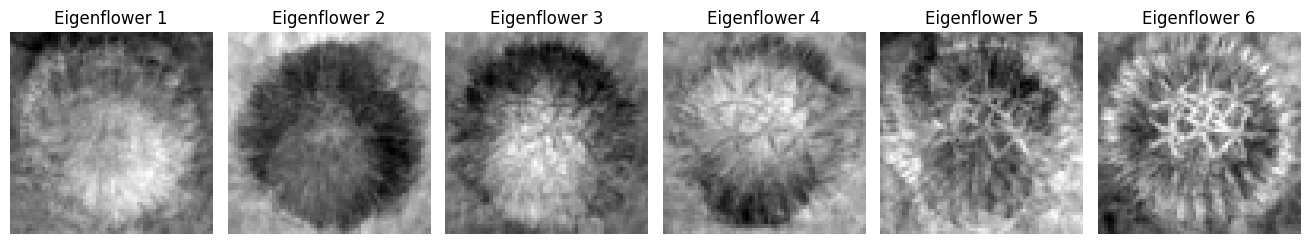

--- Method 2: Dual trick (eigh) ---


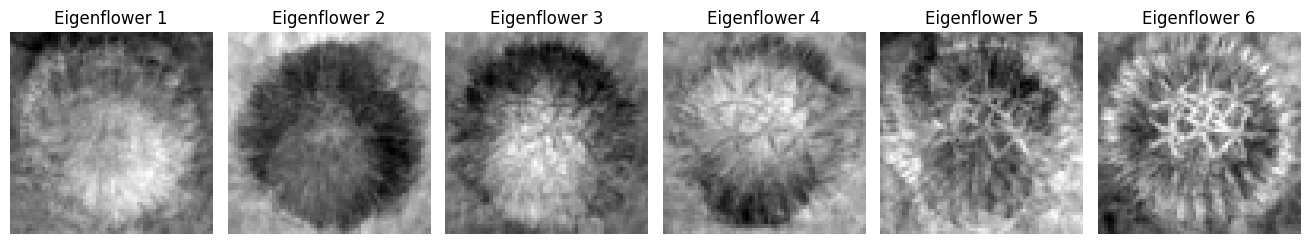

--- Method 3: Dual trick (Power Method) ---


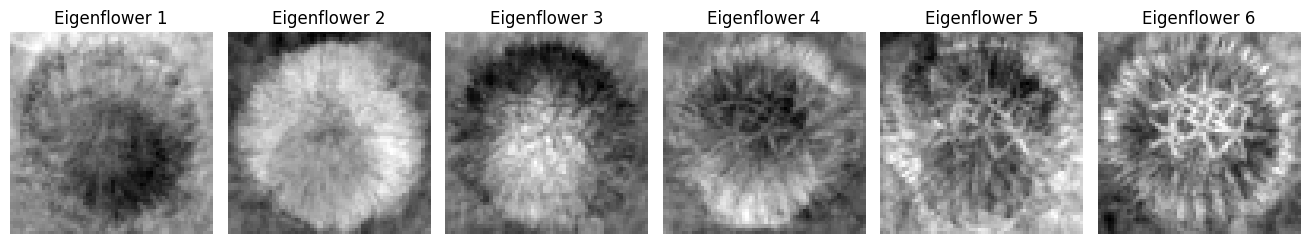

In [36]:
def show_eigenimages(U, size, k=6, title_prefix='Eigenimage'):
    k = min(k, U.shape[1])
    if k <= 0:
        print('[warn] No eigenimages to display.')
        return
    fig, axes = plt.subplots(1, k, figsize=(2.2*k, 2.8))
    if k == 1:
        axes = [axes]
    for i in range(k):
        axes[i].imshow(U[:, i].reshape(size[::-1]), cmap='gray')
        axes[i].set_title(f'{title_prefix} {i+1}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# Show top-6 eigenflowers from each of the three methods
print('--- Method 1: Thin SVD ---')
show_eigenimages(U1, OUTPUT_SIZE, k=6, title_prefix='Eigenflower')

print('--- Method 2: Dual trick (eigh) ---')
show_eigenimages(U2, OUTPUT_SIZE, k=6, title_prefix='Eigenflower')

print('--- Method 3: Dual trick (Power Method) ---')
show_eigenimages(U3, OUTPUT_SIZE, k=6, title_prefix='Eigenflower')


## 10) TODO: Reconstruction with top-k components

Pick one image, project onto top-k eigenimages, and reconstruct.  
Display your reconstructions  
Observe how reconstruction improves as k increases.


Test data shape: (4096, 18)
=== Training image reconstruction ===

--- Method 1 (SVD) ---


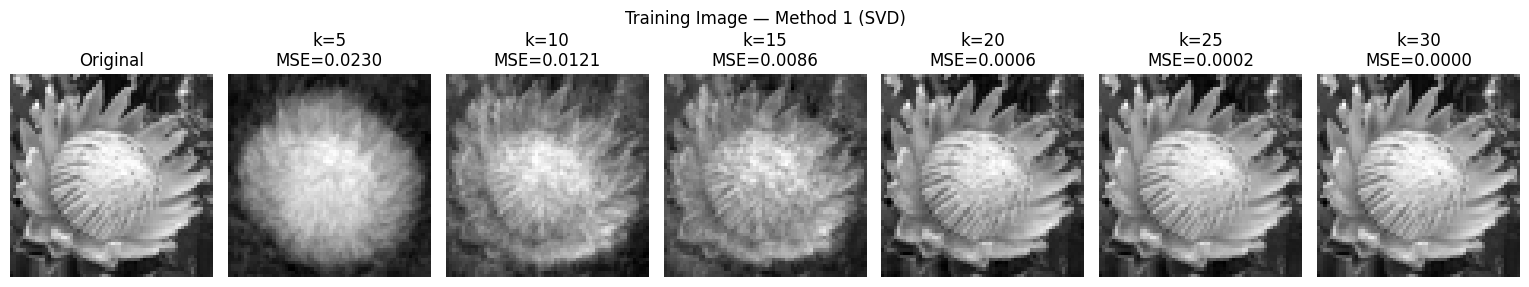

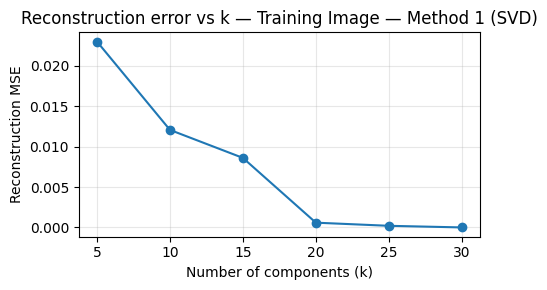

--- Method 2 (Dual eigh) ---


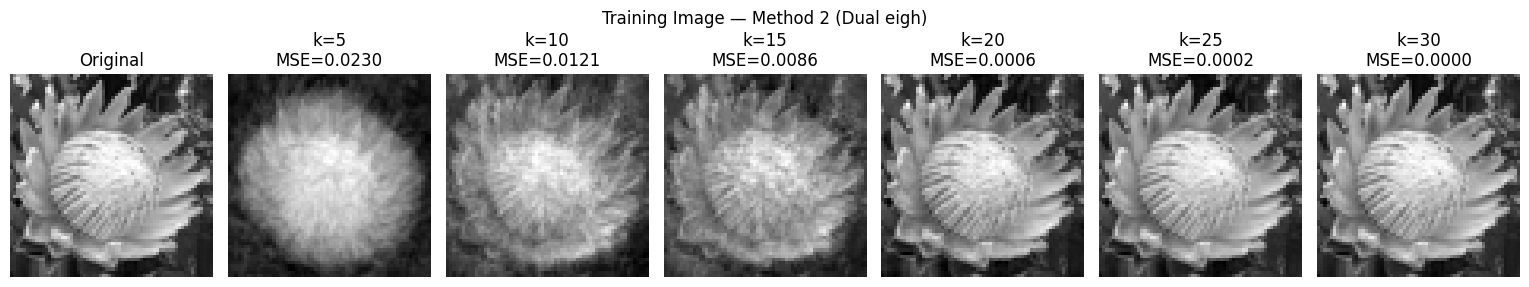

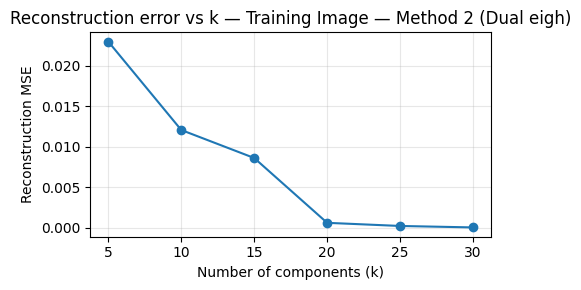

--- Method 3 (Dual Power) ---


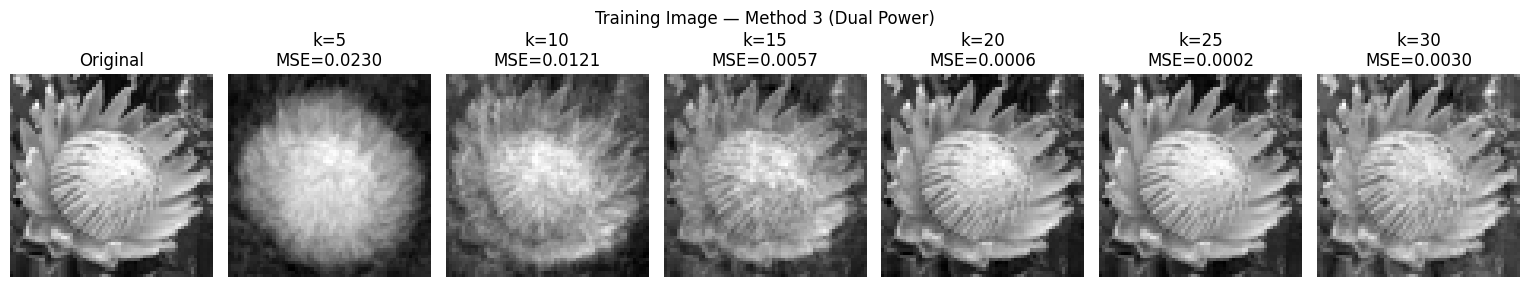

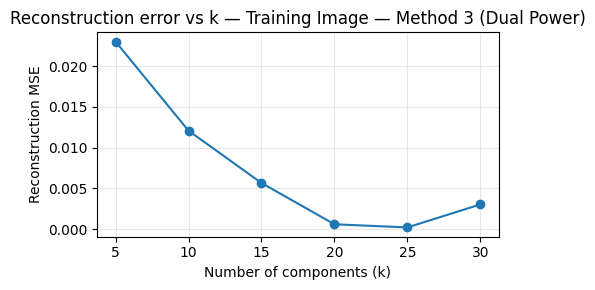


=== Test image reconstruction (never seen during training) ===

--- Method 1 (SVD) ---


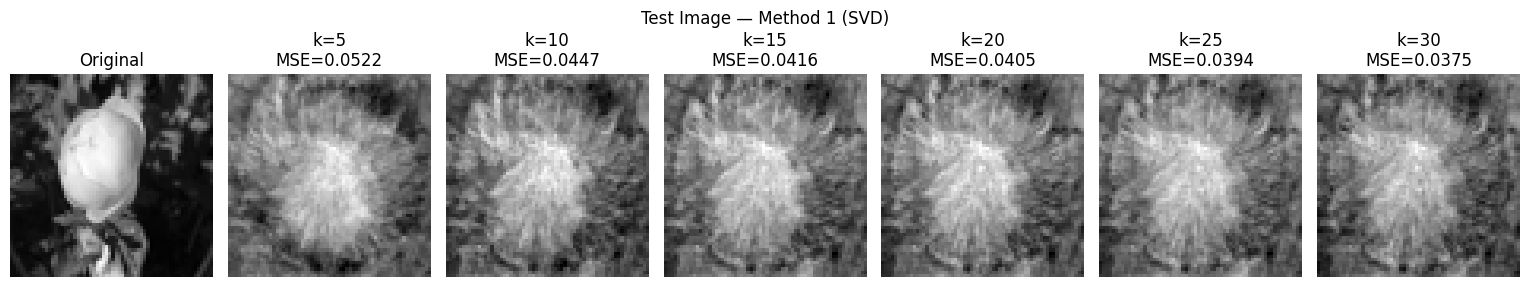

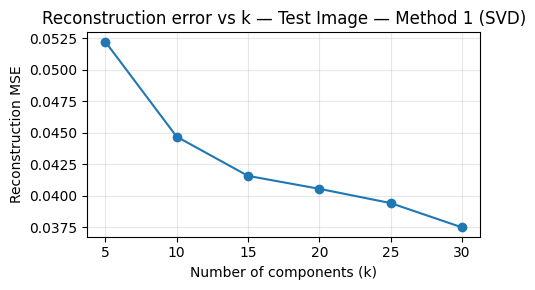

--- Method 2 (Dual eigh) ---


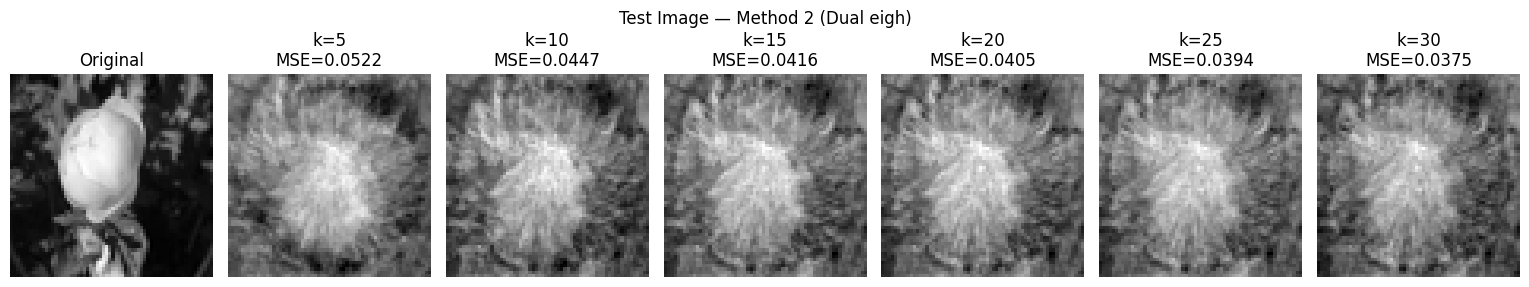

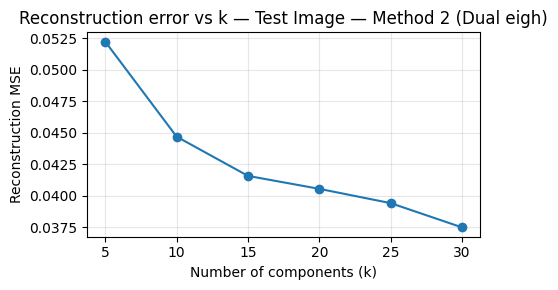

--- Method 3 (Dual Power) ---


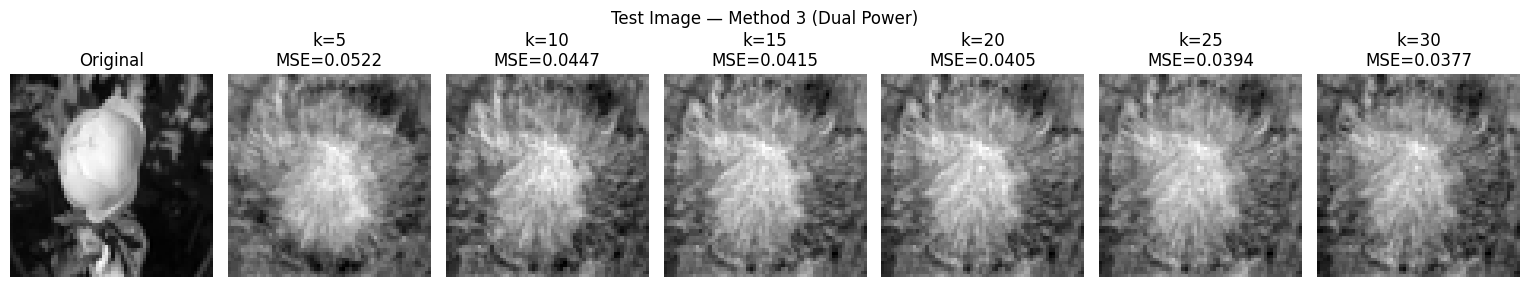

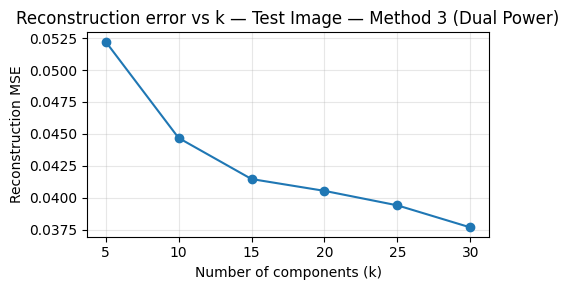


Sanity check — MSE at k=30 for each method (should be identical):
  Method 1 (SVD): MSE = 0.00000000
  Method 2 (Dual eigh): MSE = 0.00001954
  Method 3 (Dual Power): MSE = 0.00302033


In [37]:
def reconstruct_with_k(U, mean_image, x_centered, k):
    '''
    Reconstruct an image using only the top-k eigenimages.

    Steps:
      1. Project the centered image onto the k-dim PCA subspace.
      2. Reconstruct back in centered pixel space.
      3. Add the mean image to un-center the result.

    Returns:
      recon_x: reconstructed image vector (pixels,) in original pixel space
    '''
    U_k            = U[:, :k]            # top-k eigenimages  (pixels, k)
    coeffs         = U_k.T @ x_centered  # projection coefficients  (k,)
    recon_centered = U_k @ coeffs        # reconstruction in centered space
    recon_x        = recon_centered + mean_image  # add mean back
    return recon_x


# ── choose image index and k values ──────────────────────────────────────────
j  = 11
ks = [5, 10, 15, 20, 25, 30]

# ── Load test images ──────────────────────────────────────────────────────────
B, test_paths = load_and_preprocess(TEST_DIR, size=OUTPUT_SIZE, max_images=MAX_IMAGES)
B_centered    = B - mean_image[:, None]   # centre using TRAINING mean
print(f"Test data shape: {B.shape}")


def plot_reconstructions(orig, x_centered, U, mean_img, ks, suptitle):
    recons, mses = [], []
    for k in ks:
        r = reconstruct_with_k(U, mean_img, x_centered, k)
        recons.append(r)
        mses.append(float(np.mean((orig - r) ** 2)))

    cols = len(ks) + 1
    plt.figure(figsize=(2.2 * cols, 2.8))
    ax = plt.subplot(1, cols, 1)
    ax.imshow(orig.reshape(OUTPUT_SIZE[::-1]), cmap='gray')
    ax.set_title('Original'); ax.axis('off')
    for i, (k, r, mse) in enumerate(zip(ks, recons, mses), start=2):
        ax = plt.subplot(1, cols, i)
        ax.imshow(r.reshape(OUTPUT_SIZE[::-1]), cmap='gray')
        ax.set_title(f'k={k}\nMSE={mse:.4f}'); ax.axis('off')
    plt.suptitle(suptitle, y=1.02)
    plt.tight_layout(); plt.show()

    # Error curve
    plt.figure(figsize=(5, 3))
    plt.plot(ks, mses, marker='o')
    plt.xlabel('Number of components (k)')
    plt.ylabel('Reconstruction MSE')
    plt.title(f'Reconstruction error vs k — {suptitle}')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return mses


# ── Dictionary of all 3 PCA methods for reconstruction comparison ─────────────
methods = {
    'Method 1 (SVD)':          U1,
    'Method 2 (Dual eigh)':    U2,
    'Method 3 (Dual Power)':   U3,
}

# ── Reconstruct a training image with ALL 3 methods ──────────────────────────
print('=== Training image reconstruction ===\n')
j_tr = min(j, A.shape[1] - 1)
orig_tr = A[:, j_tr]
x_tr    = A_centered[:, j_tr]

for name, U_method in methods.items():
    print(f'--- {name} ---')
    _ = plot_reconstructions(orig_tr, x_tr, U_method, mean_image, ks, f'Training Image — {name}')

# ── Reconstruct a test image with ALL 3 methods ──────────────────────────────
print('\n=== Test image reconstruction (never seen during training) ===\n')
j_te = min(j, B.shape[1] - 1)
orig_te = B[:, j_te]
x_te    = B_centered[:, j_te]

for name, U_method in methods.items():
    print(f'--- {name} ---')
    _ = plot_reconstructions(orig_te, x_te, U_method, mean_image, ks, f'Test Image — {name}')

# ── Verify all 3 methods give the same MSE ────────────────────────────────────
print('\nSanity check — MSE at k=30 for each method (should be identical):')
for name, U_method in methods.items():
    r = reconstruct_with_k(U_method, mean_image, x_tr, 30)
    mse = float(np.mean((orig_tr - r) ** 2))
    print(f'  {name}: MSE = {mse:.8f}')


## 11) TODO: Explained variance; plot the cummulative explained variance   

Plot how much variation is captured by the first k components.   

$EVR_k = \frac{\lambda_k}{\sum_{i=1}^p \lambda_i}$

Cummulative $EVR_m = \frac{\sum_{k=1}^m \lambda_k}{\sum_{i=1}^p \lambda_i}$

Plot $EVR_m$ at every $m$


Total variance (sum of eigenvalues):  148.0805
Top-5 EVR:        [0.1839 0.1435 0.1164 0.0625 0.0508]
Top-5 Cumul. EVR: [0.1839 0.3274 0.4438 0.5063 0.5571]
Components for 90 % variance: 19
Components for 95 % variance: 23


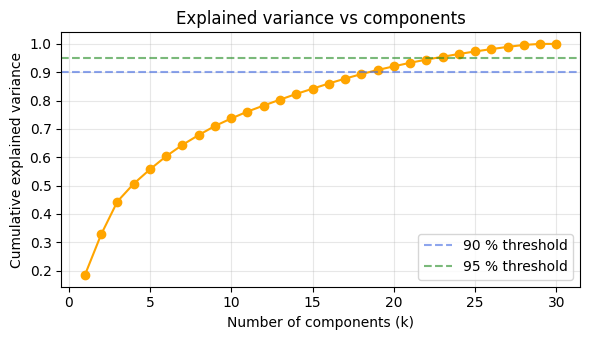

In [38]:
# Use eigenvalues from Method 1 (SVD) — most numerically stable
total_var = np.sum(eigvals1)
EVR       = eigvals1 / total_var   # per-component explained variance ratio
cummu     = np.cumsum(EVR)         # cumulative EVR

print(f"Total variance (sum of eigenvalues):  {total_var:.4f}")
print(f"Top-5 EVR:        {EVR[:5].round(4)}")
print(f"Top-5 Cumul. EVR: {cummu[:5].round(4)}")
print(f"Components for 90 % variance: {np.argmax(cummu >= 0.90) + 1}")
print(f"Components for 95 % variance: {np.argmax(cummu >= 0.95) + 1}")

# Plot cumulative EVR
plt.figure(figsize=(6, 3.5))
plt.plot(np.arange(1, len(cummu)+1), cummu, marker='o', color='orange')
plt.axhline(y=0.90, color='royalblue',   linestyle='--', alpha=0.6, label='90 % threshold')
plt.axhline(y=0.95, color='forestgreen', linestyle='--', alpha=0.6, label='95 % threshold')
plt.xlabel('Number of components (k)')
plt.ylabel('Cumulative explained variance')
plt.title('Explained variance vs components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 12) TODO: Feature Mapping
- Explain how this approach can be used for feature extraction - you can explain that here...

- What exactly are the features and how do we obtain them here?

### How PCA enables Feature Extraction

**What are the features?**

After fitting PCA on the training matrix $A$, every image
$x \in \mathbb{R}^p$ (where $p = $ pixels) is mapped to a compact
$k$-dimensional feature vector $z \in \mathbb{R}^k$ via the linear projection:

$$z = U_k^\top (x - \bar{x})$$

where:
- $\bar{x}$ is the **mean image** (computed from training data only)
- $U_k \in \mathbb{R}^{p \times k}$ contains the top-$k$ **eigenimages** as columns
- Each $z_i = u_i^\top (x - \bar{x})$ is a **projection coefficient** — how strongly
  image $x$ resembles the $i$-th eigenflower

The resulting $k$-dimensional vector $z$ **is the feature representation** of the image.
Each coordinate $z_i$ measures the image's alignment with the $i$-th principal direction of
variance in the training set.

**How do we obtain them?**

1. **Fit (train):** compute $\bar{x}$ and $U_k$ from training matrix $A$.
2. **Transform:** for any image $x$ (train *or* test), centre it
   ($x_c = x - \bar{x}$), then project: $z = U_k^\top x_c$.
3. **Use the features** for downstream pattern recognition tasks:
   - **Flower species classification** — feed the $k$-dim vector $z$ into
     k-NN, SVM, or logistic regression to classify flower species.
     Because PCA preserves the directions of maximum variance, classes that
     are separated in pixel space remain separated (often better) in the
     reduced PCA space.
   - **Clustering** — run k-means on $z$ to discover natural groupings
   - **Anomaly / novelty detection** — an image with unusually high
     reconstruction error $\|x - \hat{x}\|$ is likely an outlier or a
     flower species not seen during training
   - **Visualisation** — scatter the 2-D projection (or T-SNE of $z$) to
     inspect class separability before building a classifier

**Why is this useful in pattern recognition?**

Raw pixel vectors live in a $p$-dimensional space ($p=4096$ for 64×64 images).
Most classifiers suffer from the **curse of dimensionality** in such high-dimensional
spaces — distances become less meaningful and overfitting increases.
PCA reduces the input to $k \ll p$ dimensions while retaining the most
discriminative variance, making downstream classifiers both faster and more
accurate.

**Reconstruction:**

$$\hat{x} = U_k z + \bar{x} = U_k U_k^\top (x - \bar{x}) + \bar{x}$$

The reconstruction error quantifies how much information is lost when compressing
from $p$ to $k$ dimensions.

In [39]:
# ── Feature extraction demo ───────────────────────────────────────────────────
k_feat  = 10
U_k_feat = U1[:, :k_feat]

Z_train = U_k_feat.T @ A_centered   # (k, M_train)
Z_test  = U_k_feat.T @ B_centered   # (k, M_test)

print(f"Original pixel space:  {A.shape[0]} dimensions")
print(f"PCA feature space:     {k_feat} dimensions")
print(f"Z_train shape:         {Z_train.shape}  (k × M_train)")
print(f"Z_test  shape:         {Z_test.shape}  (k × M_test)")

print('\nFeature vectors for first 3 training images:')
for i in range(3):
    print(f'  Image {i}: {Z_train[:, i].round(3)}')

Original pixel space:  4096 dimensions
PCA feature space:     10 dimensions
Z_train shape:         (10, 30)  (k × M_train)
Z_test  shape:         (10, 18)  (k × M_test)

Feature vectors for first 3 training images:
  Image 0: [ 1.822 -2.127  2.392 -0.355  2.735 -4.315  1.489 -3.607  3.296 -3.344]
  Image 1: [ 5.815 -2.073 -2.385  0.225 -1.001 -1.061 -1.151 -1.635  0.731 -3.955]
  Image 2: [-2.373 -7.383  0.169 -4.448 -0.224  1.771  1.399 -1.532  3.903  2.054]


---
## 13) Common Distributions from the Exponential Family

A distribution belongs to the **exponential family** if its PDF/PMF can be written in the
canonical form:

$$p(x \mid \boldsymbol{\eta}) \;=\; h(x)\;\exp\!\Big(\boldsymbol{\eta}^\top T(x) \;-\; A(\boldsymbol{\eta})\Big)$$

where:
- $\boldsymbol{\eta}$ — **natural (canonical) parameter(s)**
- $T(x)$ — **sufficient statistic(s)**
- $A(\boldsymbol{\eta})$ — **log-partition function** (ensures the distribution normalises to 1)
- $h(x)$ — **base measure** (independent of the parameter)

For each distribution below we give the standard form, parameters, discrete/continuous
type, a use-case description, **and** the exponential-family decomposition.

### (a) Gaussian (Normal) Distribution

$$p(x \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Parameters:** $\mu \in \mathbb{R}$ (mean/location),  $\sigma^2 > 0$ (variance/scale).

**Type:** Continuous.

**When to use:** Models data arising from many small, independent additive effects (justified by the Central Limit Theorem). Use it for regression targets, measurement noise, latent variables in generative models (VAE), and any roughly symmetric, bell-shaped data.

**Exponential-family form** (with both $\mu$ and $\sigma^2$ as parameters):

| Component | Value |
|-----------|-------|
| $T(x)$ | $(x,\; x^2)$ |
| $\boldsymbol{\eta}$ | $\left(\dfrac{\mu}{\sigma^2},\; -\dfrac{1}{2\sigma^2}\right)$ |
| $A(\boldsymbol{\eta})$ | $\dfrac{\mu^2}{2\sigma^2} + \dfrac{1}{2}\ln(2\pi\sigma^2) = -\dfrac{\eta_1^2}{4\eta_2} + \dfrac{1}{2}\ln\!\left(\dfrac{-\pi}{\eta_2}\right)$ |
| $h(x)$ | $1$ |

### (b) Bernoulli Distribution

$$p(x \mid \theta) = \theta^{x}(1-\theta)^{1-x}, \quad x \in \{0, 1\}$$

**Parameters:** $\theta \in [0,1]$ — probability of success ($x=1$).

**Type:** Discrete.

**When to use:** Models a single binary trial (yes/no, heads/tails, click/no-click). It is the building block for the Binomial and is used as the output distribution in binary classification (paired with a sigmoid activation).

**Exponential-family form:**

| Component | Value |
|-----------|-------|
| $T(x)$ | $x$ |
| $\eta$ | $\ln\!\dfrac{\theta}{1-\theta}$ (log-odds / logit) |
| $A(\eta)$ | $\ln(1+e^{\eta}) = -\ln(1-\theta)$ |
| $h(x)$ | $1$ |

### (c) Binomial Distribution

$$p(k \mid n,\theta) = \binom{n}{k}\theta^{k}(1-\theta)^{n-k}, \quad k \in \{0,\ldots,n\}$$

**Parameters:** $n \in \mathbb{Z}^+$ (number of trials), $\theta \in [0,1]$ (success probability per trial).

**Type:** Discrete.

**When to use:** Models the **number of successes** in $n$ independent Bernoulli trials (e.g., correct predictions out of $n$ test cases, defective items in a batch).

**Exponential-family form** (treating $n$ as fixed and $\theta$ as the parameter):

| Component | Value |
|-----------|-------|
| $T(k)$ | $k$ |
| $\eta$ | $\ln\!\dfrac{\theta}{1-\theta}$ (logit) |
| $A(\eta)$ | $n\ln(1+e^{\eta}) = -n\ln(1-\theta)$ |
| $h(k)$ | $\dbinom{n}{k}$ |

### (d) Multinomial Distribution

$$p(x_1,\ldots,x_K \mid n,\boldsymbol{\theta}) = \frac{n!}{x_1!\cdots x_K!}\prod_{k=1}^{K}\theta_k^{x_k}, \quad \sum_k x_k = n,\; \sum_k \theta_k = 1$$

**Parameters:** $n$ (total trials), $\boldsymbol{\theta}=(\theta_1,\ldots,\theta_K)$ (simplex probabilities).

**Type:** Discrete (multivariate).

**When to use:** Generalises the Binomial to $K>2$ categories. Widely used in NLP (word counts in a document), multi-class classification (softmax output), and topic models such as LDA.

**Exponential-family form** (with $n$ fixed; using $K-1$ free parameters since $\theta_K = 1 - \sum_{k=1}^{K-1}\theta_k$):

| Component | Value |
|-----------|-------|
| $T(\mathbf{x})$ | $(x_1, x_2, \ldots, x_{K-1})$ |
| $\boldsymbol{\eta}$ | $\left(\ln\dfrac{\theta_1}{\theta_K},\; \ldots,\; \ln\dfrac{\theta_{K-1}}{\theta_K}\right)$ |
| $A(\boldsymbol{\eta})$ | $n\ln\!\left(1 + \sum_{k=1}^{K-1}e^{\eta_k}\right)$ |
| $h(\mathbf{x})$ | $\dfrac{n!}{x_1!\cdots x_K!}$ |

### (e) Exponential Distribution

$$p(x \mid \lambda) = \lambda\,e^{-\lambda x}, \quad x \ge 0$$

**Parameters:** $\lambda > 0$ — rate (inverse of mean; $\mathbb{E}[x] = 1/\lambda$).

**Type:** Continuous.

**When to use:** Models **waiting / inter-arrival times** in a Poisson process. Has the memoryless property $P(X>s+t\mid X>s)=P(X>t)$. Use it for time-to-failure, survival analysis, or service-time modelling.

**Exponential-family form:**

| Component | Value |
|-----------|-------|
| $T(x)$ | $x$ |
| $\eta$ | $-\lambda$ |
| $A(\eta)$ | $-\ln(-\eta) = -\ln\lambda$ |
| $h(x)$ | $\mathbf{1}[x \ge 0]$ (indicator) |

### (f) Poisson Distribution

$$p(k \mid \lambda) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \ldots\}$$

**Parameters:** $\lambda > 0$ — rate (equals both mean and variance: $\mathbb{E}[k] = \operatorname{Var}(k) = \lambda$).

**Type:** Discrete.

**When to use:** Models the **count of events** in a fixed interval at a constant average rate. Classic applications: emails per hour, defects per unit area, photon counts in an image sensor, customer arrivals per minute.

**Exponential-family form:**

| Component | Value |
|-----------|-------|
| $T(k)$ | $k$ |
| $\eta$ | $\ln\lambda$ |
| $A(\eta)$ | $e^{\eta} = \lambda$ |
| $h(k)$ | $\dfrac{1}{k!}$ |

---
## Bonus (5 pts): T-SNE Map of All Training Data Vectors in A

**T-SNE** (t-Distributed Stochastic Neighbor Embedding) is a non-linear
dimensionality-reduction technique well-suited for 2-D visualisation of
high-dimensional data.  We plot the T-SNE map of every column of $A$
(i.e., all 30 training images), colouring each point by its ground-truth
flower class as given in `train.csv`.

Class labels: [3 3 3 3 3 1 1 1 1 1 4 4 4 4 4 5 5 5 5 5 0 0 0 0 0 2 2 2 2 2]
Unique classes: [0 1 2 3 4 5]
Running T-SNE on raw pixel vectors …


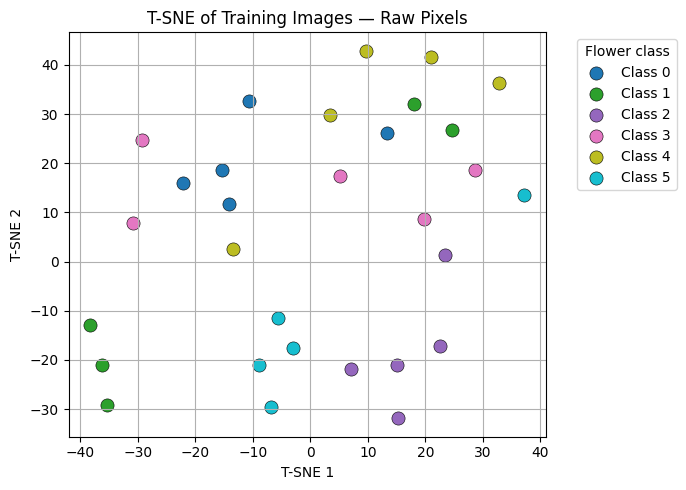

Running T-SNE on top-15 PCA features …


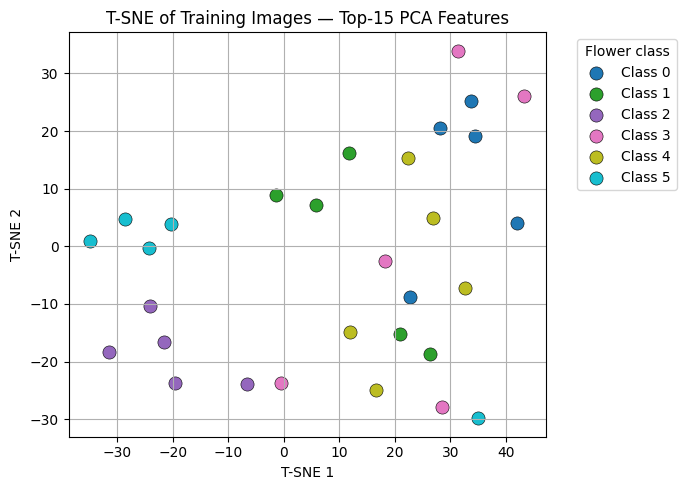

In [40]:
# ── Bonus: T-SNE visualisation ────────────────────────────────────────────────
from sklearn.manifold import TSNE  # only needed for this bonus section

# ── Load class labels from train.csv ─────────────────────────────────────────
import csv
label_map = {}  # filename -> int label
with open(os.path.join(DATA_DIR, 'train.csv')) as f:
    for row in csv.DictReader(f):
        label_map[row['filename']] = int(row['label'])

train_labels = np.array([label_map[os.path.basename(p)] for p in paths])
unique_cls   = np.unique(train_labels)
print("Class labels:", train_labels)
print("Unique classes:", unique_cls)

palette = plt.cm.tab10(np.linspace(0, 1, len(unique_cls)))


def tsne_scatter(Z2d, labels, unique_cls, palette, title):
    plt.figure(figsize=(7, 5))
    for i, cls in enumerate(unique_cls):
        mask = labels == cls
        plt.scatter(Z2d[mask, 0], Z2d[mask, 1],
                    color=palette[i], label=f'Class {cls}',
                    s=90, edgecolors='k', linewidths=0.4)
    plt.title(title)
    plt.xlabel('T-SNE 1'); plt.ylabel('T-SNE 2')
    plt.legend(title='Flower class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout(); plt.show()


perp = min(5, len(paths) - 1)   # perplexity must be < n_samples

# ── T-SNE on raw pixel vectors ────────────────────────────────────────────────
print('Running T-SNE on raw pixel vectors …')
tsne_raw = TSNE(n_components=2, random_state=SEED, perplexity=perp,
                max_iter=1000, init='random')
Z_raw = tsne_raw.fit_transform(A.T)   # (M, 2)
tsne_scatter(Z_raw, train_labels, unique_cls, palette,
             'T-SNE of Training Images — Raw Pixels')

# ── T-SNE on PCA-projected features (often produces cleaner clusters) ─────────
k_pca_tsne = min(15, U1.shape[1])
Z_pca_feat = (U1[:, :k_pca_tsne].T @ A_centered).T   # (M, k)
print(f"Running T-SNE on top-{k_pca_tsne} PCA features …")
tsne_pca = TSNE(n_components=2, random_state=SEED, perplexity=perp,
                max_iter=1000, init='random')
Z_pca2 = tsne_pca.fit_transform(Z_pca_feat)   # (M, 2)
tsne_scatter(Z_pca2, train_labels, unique_cls, palette,
             f'T-SNE of Training Images — Top-{k_pca_tsne} PCA Features')